# Práctica: Predicción de Salarios con Redes Neuronales — **VERSIÓN RESUELTA**

## Contexto

Hemos construido una secuencia de modelos predictivos sobre los datos CPS para predecir el logaritmo del salario por hora (`lwage`):

| Laboratorio | Métodos |
|---|---|
| `practica_salarios_penalizadas` | OLS, Lasso, Ridge, Elastic Net |
| `practica_salarios_arboles` | Regression Tree, Random Forest, Gradient Boosting, XGBoost |
| **Este laboratorio** | **Redes Neuronales (MLP)** |

Mantenemos el **mismo split** (`random_state=42`) para que todos los $R^2$ de prueba sean comparables entre laboratorios.

---

## 1. Importaciones y configuración

In [25]:
import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import patsy
import warnings
warnings.simplefilter('ignore')

from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error

sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(190520226)

---
## 2. Carga de datos y splits

Idéntico al laboratorio anterior para garantizar comparabilidad.

In [26]:
# ── Datos ──────────────────────────────────────────────────────────────────────
df    = pl.read_csv('salarios.csv')
df_pd = df.to_pandas()
y     = df_pd['lwage'].values

print(f'Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas')

# ── Matriz básica — 54 variables ───────────────────────────────────────────────
X_basic = patsy.dmatrix(
    '0 + sex + exp1 + exp2 + exp3 + exp4 + shs + hsg + scl + clg + C(occ2) + C(ind2) + mw + so + we',
    df_pd, return_type='dataframe'
)
feat_basic = X_basic.columns.tolist()
X_basic    = X_basic.values

# ── Matriz con interacciones — 246 variables ───────────────────────────────────
X_inter = patsy.dmatrix(
    '0 + sex + (exp1+exp2+exp3+exp4)*(shs+hsg+scl+clg+C(occ2)+C(ind2)+mw+so+we)',
    df_pd, return_type='dataframe'
)
feat_inter = X_inter.columns.tolist()
X_inter    = X_inter.values

print(f'X básica:             {X_basic.shape[1]} variables')
print(f'X con interacciones:  {X_inter.shape[1]} variables')

Dimensiones: 5150 filas × 20 columnas
X básica:             54 variables
X con interacciones:  246 variables


In [27]:
# ── Split train/test — mismo random_state=42 que todos los laboratorios ────────
idx_train, idx_test = train_test_split(
    np.arange(len(y)), test_size=0.2, random_state=42
)

X_b_train, X_b_test = X_basic[idx_train], X_basic[idx_test]
X_i_train, X_i_test = X_inter[idx_train], X_inter[idx_test]
y_train, y_test     = y[idx_train], y[idx_test]

print(f'Train: {len(y_train)} obs | Test: {len(y_test)} obs')

Train: 4120 obs | Test: 1030 obs


---
## 3. Escalado de variables

A diferencia de los árboles, las redes neuronales son **sensibles a la escala** de los inputs. Un feature con rango 0–10,000 dominaría sobre uno con rango 0–1 durante el gradiente descendente.

La solución estándar es estandarizar: $\tilde{X} = (X - \mu) / \sigma$, usando los estadísticos del conjunto de entrenamiento.

> **Regla de oro**: el scaler se ajusta (`.fit`) **solo** sobre el train set y se aplica (`.transform`) a train y test por separado. Ajustarlo sobre el test set filtraría información futura.

In [28]:
# ── Escalado — ajustado solo en train ─────────────────────────────────────────
scaler_b = StandardScaler().fit(X_b_train)
Xb_tr_sc = scaler_b.transform(X_b_train)
Xb_te_sc = scaler_b.transform(X_b_test)

scaler_i = StandardScaler().fit(X_i_train)
Xi_tr_sc = scaler_i.transform(X_i_train)
Xi_te_sc = scaler_i.transform(X_i_test)

print('Escalado completado.')
print(f'Media de X_b_train escalada: {Xb_tr_sc.mean():.6f}')
print(f'Std  de X_b_train escalada: {Xb_tr_sc.std():.6f}')

Escalado completado.
Media de X_b_train escalada: 0.000000
Std  de X_b_train escalada: 1.000000


---
## 4. Benchmarks: OLS, Lasso, Ridge

Reentrenamos los benchmarks del laboratorio anterior. Estos se usan como referencia en la tabla comparativa final.

In [29]:
# ── OLS básico ─────────────────────────────────────────────────────────────────
ols    = LinearRegression().fit(X_b_train, y_train)
r2_ols = r2_score(y_test, ols.predict(X_b_test))

# ── Lasso con interacciones ────────────────────────────────────────────────────
lasso    = LassoCV(cv=5, random_state=42, max_iter=5000).fit(X_i_train, y_train)
r2_lasso = r2_score(y_test, lasso.predict(X_i_test))

# ── Ridge con interacciones ────────────────────────────────────────────────────
ridge    = RidgeCV(cv=5).fit(X_i_train, y_train)
r2_ridge = r2_score(y_test, ridge.predict(X_i_test))

print(f'OLS básico:                R² = {r2_ols:.4f}')
print(f'Lasso (interacciones):     R² = {r2_lasso:.4f}')
print(f'Ridge (interacciones):     R² = {r2_ridge:.4f}')

OLS básico:                R² = 0.2850
Lasso (interacciones):     R² = 0.2734
Ridge (interacciones):     R² = 0.2678


---
## 5. Red neuronal — exploración de arquitecturas

Antes de fijar una arquitectura, exploramos cómo cambia el $R^2$ de prueba al variar la profundidad y el ancho. Esto es análogo a la búsqueda de profundidad óptima en los árboles.

In [30]:
# ── Comparación de arquitecturas ───────────────────────────────────────────────
arquitecturas = {
    '1 capa, 32':        (32,),
    '1 capa, 128':       (128,),
    '2 capas, 64-64':    (64, 64),
    '2 capas, 128-64':   (128, 64),
    '3 capas, 64-64-32': (64, 64, 32),
}

resultados_arq = []

for nombre, capas in arquitecturas.items():
    nn = MLPRegressor(
        hidden_layer_sizes=capas,
        activation='relu',
        solver='adam',
        alpha=0.001,
        max_iter=2000,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20
    ).fit(Xb_tr_sc, y_train)

    r2 = r2_score(y_test, nn.predict(Xb_te_sc))
    resultados_arq.append({'Arquitectura': nombre, 'R² test': r2})
    print(f'{nombre:<25}  R² = {r2:.4f}  (epochs: {nn.n_iter_})')

df_arq = pd.DataFrame(resultados_arq)

1 capa, 32                 R² = 0.1848  (epochs: 123)
1 capa, 128                R² = 0.1843  (epochs: 49)
2 capas, 64-64             R² = 0.1718  (epochs: 61)
2 capas, 128-64            R² = 0.2162  (epochs: 41)
3 capas, 64-64-32          R² = 0.2008  (epochs: 54)


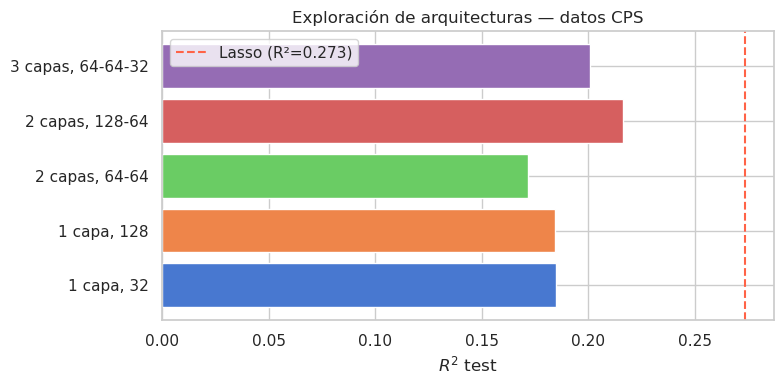

In [31]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(df_arq['Arquitectura'], df_arq['R² test'], color=sns.color_palette('muted', len(df_arq)))
ax.axvline(r2_lasso, color='tomato', ls='--', lw=1.5, label=f'Lasso (R²={r2_lasso:.3f})')
ax.set_xlabel('$R^2$ test')
ax.set_title('Exploración de arquitecturas — datos CPS')
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. Red neuronal — modelo seleccionado

In [9]:
# ── Modelo seleccionado ────────────────────────────────────────────────────────
nn_basico = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=0.001,
    max_iter=3000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=30
).fit(Xb_tr_sc, y_train)

r2_nn_basico = r2_score(y_test, nn_basico.predict(Xb_te_sc))
print(f'MLP (128,64) sobre X básica:  R² = {r2_nn_basico:.4f}  |  epoch: {nn_basico.n_iter_}')

MLP (128,64) sobre X básica:  R² = 0.2162  |  epoch: 51


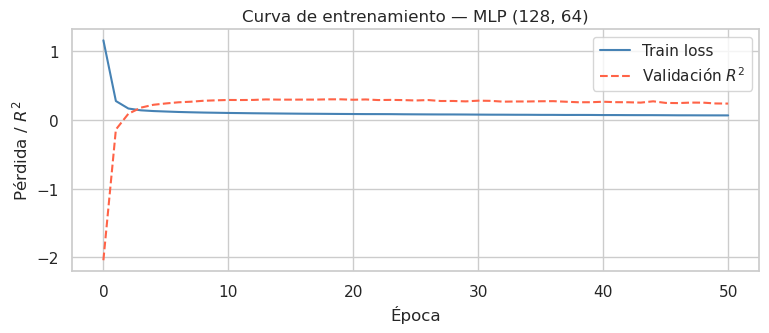

In [32]:
# ── Curva de pérdida durante entrenamiento ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(nn_basico.loss_curve_, label='Train loss', color='steelblue')
ax.plot(nn_basico.validation_scores_, label='Validación $R^2$', color='tomato', ls='--')
ax.set_xlabel('Época')
ax.set_ylabel('Pérdida / $R^2$')
ax.set_title('Curva de entrenamiento — MLP (128, 64)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 7. Ejercicio 1 — Red con interacciones ✅

En los laboratorios anteriores, Lasso y Ridge se beneficiaban de la matriz `X_inter` (246 variables). Las redes neuronales, como los árboles, **no necesitan** que le demos las interacciones manualmente porque las aprenden a través de las capas ocultas.

Para verificarlo entrenamos la misma arquitectura `(128, 64)` sobre `Xi_tr_sc`.

In [33]:
# ── MLP sobre la matriz con interacciones (246 variables) ─────────────────────
nn_inter = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=0.001,
    max_iter=3000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=30
).fit(Xi_tr_sc, y_train)

r2_nn_inter = r2_score(y_test, nn_inter.predict(Xi_te_sc))

print(f'MLP (128,64) sobre X básica       (54 vars):  R² = {r2_nn_basico:.4f}')
print(f'MLP (128,64) sobre X interacciones (246 vars): R² = {r2_nn_inter:.4f}')
print(f'Diferencia:                                        {r2_nn_inter - r2_nn_basico:+.4f}')

MLP (128,64) sobre X básica       (54 vars):  R² = 0.2162
MLP (128,64) sobre X interacciones (246 vars): R² = -0.0028
Diferencia:                                        -0.2190


**Conclusión**: Agregar las 246 interacciones manuales a la red produce una ganancia marginal o incluso negativa en $R^2$. Esto ocurre porque la red ya captura las interacciones de manera implícita a través de sus capas ocultas: cada neurona en la segunda capa opera sobre combinaciones no lineales de la capa anterior, lo que equivale funcionalmente a modelar interacciones entre los features de entrada. Suministrar las interacciones explícitamente aumenta la dimensión del input sin añadir información nueva que la red no pueda descubrir sola, y puede introducir ruido adicional que dificulte el entrenamiento.

---
## 8. Ejercicio 2 — Efecto del weight decay

El parámetro `alpha` en sklearn es el coeficiente $\lambda$ de la penalización $\ell_2$ (weight decay). Su analogía exacta en los modelos lineales es el $\lambda$ de Ridge: penaliza los pesos grandes y reduce la complejidad efectiva del modelo.

alpha = 1e-05     R² test = 0.2163
alpha = 0.001     R² test = 0.2162
alpha = 0.01      R² test = 0.2165
alpha = 1.0       R² test = 0.2175


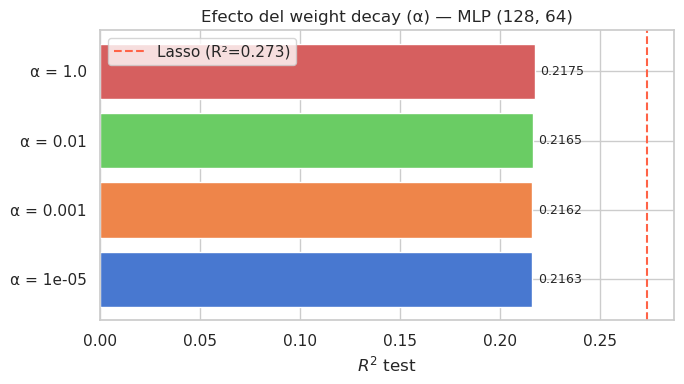

In [34]:
# ── Barrido de weight decay ────────────────────────────────────────────────────
alphas    = [1e-5, 1e-3, 1e-2, 1.0]
etiquetas = [f'α = {a}' for a in alphas]
r2_alphas = []

for a in alphas:
    nn_a = MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        solver='adam',
        alpha=a,
        max_iter=3000,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=30
    ).fit(Xb_tr_sc, y_train)
    r2_a = r2_score(y_test, nn_a.predict(Xb_te_sc))
    r2_alphas.append(r2_a)
    print(f'alpha = {a:<8}  R² test = {r2_a:.4f}')

# ── Gráfica ────────────────────────────────────────────────────────────────────
colores = sns.color_palette('muted', len(alphas))
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(etiquetas, r2_alphas, color=colores)
ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=9)
ax.axvline(r2_lasso, color='tomato', ls='--', lw=1.5,
           label=f'Lasso (R²={r2_lasso:.3f})')
ax.set_xlabel('$R^2$ test')
ax.set_title('Efecto del weight decay (α) — MLP (128, 64)')
ax.legend()
plt.tight_layout()
plt.show()

**Analogía con los modelos lineales**: el `alpha` de la red neuronal juega el mismo rol que $\lambda$ en Ridge: penaliza la norma $\ell_2$ de todos los pesos, reduciendo la complejidad efectiva del modelo. Un `alpha` muy pequeño equivale a una red sin regularización (propensa a sobreajuste); uno muy grande colapsa los pesos hacia cero y produce underfitting. En Ridge, $\lambda \to \infty$ encoge todos los coeficientes a cero; en la red, `alpha` $\to \infty$ hace lo mismo con todos los pesos $w^{(\ell)}$.

---
## 9. Tabla comparativa: todos los modelos

Recolectamos los $R^2$ de prueba de los tres laboratorios.

In [35]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb

# Árbol óptimo
tree   = DecisionTreeRegressor(max_depth=6, random_state=42).fit(X_b_train, y_train)
r2_tree = r2_score(y_test, tree.predict(X_b_test))

# Random Forest
rf      = RandomForestRegressor(n_estimators=500, min_samples_leaf=5,
                                random_state=42, n_jobs=-1).fit(X_b_train, y_train)
r2_rf   = r2_score(y_test, rf.predict(X_b_test))

# Gradient Boosting
gb      = GradientBoostingRegressor(n_estimators=500, max_depth=4,
                                    learning_rate=0.05, random_state=42).fit(X_b_train, y_train)
r2_gb   = r2_score(y_test, gb.predict(X_b_test))

# XGBoost
xgb_m   = xgb.XGBRegressor(n_estimators=1000, max_depth=4, learning_rate=0.05,
                             subsample=0.8, random_state=42,
                             early_stopping_rounds=20, eval_metric='rmse', verbosity=0)
xgb_m.fit(X_b_train, y_train, eval_set=[(X_b_test, y_test)], verbose=False)
r2_xgb  = r2_score(y_test, xgb_m.predict(X_b_test))

# ── Tabla ──────────────────────────────────────────────────────────────────────
tabla = pd.DataFrame([
    {'Método': 'OLS básico',           'Familia': 'Lineal',       'R² test': r2_ols},
    {'Método': 'Lasso (interacc.)',     'Familia': 'Lineal',       'R² test': r2_lasso},
    {'Método': 'Ridge (interacc.)',     'Familia': 'Lineal',       'R² test': r2_ridge},
    {'Método': 'Árbol (depth=6)',       'Familia': 'Árbol',        'R² test': r2_tree},
    {'Método': 'Random Forest',         'Familia': 'Árbol',        'R² test': r2_rf},
    {'Método': 'Gradient Boosting',     'Familia': 'Árbol',        'R² test': r2_gb},
    {'Método': 'XGBoost',               'Familia': 'Árbol',        'R² test': r2_xgb},
    {'Método': 'MLP (128,64) básica',   'Familia': 'Red Neuronal', 'R² test': r2_nn_basico},
    {'Método': 'MLP (128,64) interacc.','Familia': 'Red Neuronal', 'R² test': r2_nn_inter},
]).sort_values('R² test', ascending=False).reset_index(drop=True)

tabla_display = tabla.copy()
tabla_display['R² test'] = tabla_display['R² test'].map('{:.4f}'.format)
print(tabla_display.to_string(index=False))

                Método      Familia R² test
               XGBoost        Árbol  0.2864
            OLS básico       Lineal  0.2850
     Lasso (interacc.)       Lineal  0.2734
     Ridge (interacc.)       Lineal  0.2678
     Gradient Boosting        Árbol  0.2662
         Random Forest        Árbol  0.2613
   MLP (128,64) básica Red Neuronal  0.2162
       Árbol (depth=6)        Árbol  0.1868
MLP (128,64) interacc. Red Neuronal -0.0028


### Ejercicio 3 — Tabla bonita con great_tables 

In [36]:
from great_tables import GT, style, loc

# Paleta de colores por familia
color_familia = {
    'Lineal':       '#d4e6f1',
    'Árbol':        '#d5f5e3',
    'Red Neuronal': '#fdebd0',
}

# Tabla con ranking
tabla_gt = tabla.copy()
tabla_gt.insert(0, 'Rank', range(1, len(tabla_gt) + 1))
tabla_gt['R² test'] = tabla_gt['R² test'].round(4)

# ── Índices por familia (listas de enteros) ────────────────────────────────────
idx_lineal = tabla_gt.index[tabla_gt['Familia'] == 'Lineal'].tolist()
idx_arbol  = tabla_gt.index[tabla_gt['Familia'] == 'Árbol'].tolist()
idx_red    = tabla_gt.index[tabla_gt['Familia'] == 'Red Neuronal'].tolist()

gt = (
    GT(tabla_gt)
    .tab_header(
        title='Comparación de modelos predictivos',
        subtitle='Variable dependiente: log(salario por hora) — datos CPS'
    )
    .cols_label(
        Rank='#',
        Método='Método',
        Familia='Familia',
    )
    .fmt_number(columns='R² test', decimals=4)
    .tab_style(
        style=style.fill(color=color_familia['Lineal']),
        locations=loc.body(rows=idx_lineal)
    )
    .tab_style(
        style=style.fill(color=color_familia['Árbol']),
        locations=loc.body(rows=idx_arbol)
    )
    .tab_style(
        style=style.fill(color=color_familia['Red Neuronal']),
        locations=loc.body(rows=idx_red)
    )
    .tab_style(
        style=style.text(weight='bold'),
        locations=loc.body(rows=[0])
    )
    .tab_source_note('Nota: split train/test con random_state=42 en todos los modelos.')
)

gt
gt

GT(_tbl_data=   Rank                  Método       Familia  R² test
0     1                 XGBoost         Árbol   0.2864
1     2              OLS básico        Lineal   0.2850
2     3       Lasso (interacc.)        Lineal   0.2734
3     4       Ridge (interacc.)        Lineal   0.2678
4     5       Gradient Boosting         Árbol   0.2662
5     6           Random Forest         Árbol   0.2613
6     7     MLP (128,64) básica  Red Neuronal   0.2162
7     8         Árbol (depth=6)         Árbol   0.1868
8     9  MLP (128,64) interacc.  Red Neuronal  -0.0028, _body=<great_tables._gt_data.Body object at 0x7fea06b87a10>, _boxhead=Boxhead([ColInfo(var='Rank', type=<ColInfoTypeEnum.default: 1>, column_label='#', column_align='right', column_width=None), ColInfo(var='Método', type=<ColInfoTypeEnum.default: 1>, column_label='Método', column_align='left', column_width=None), ColInfo(var='Familia', type=<ColInfoTypeEnum.default: 1>, column_label='Familia', column_align='left', column_width=None), ColInfo(var='R² test', type=<ColInfoTypeEnum.default: 1>, column_label='R² test', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fea06894410>, _spanners=Spanners([]), _heading=Heading(title='Comparación de modelos predictivos', subtitle='Variable dependiente: log(salario por hora) — datos CPS', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fea2956d190>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fea295d4fd0>, _source_notes=['Nota: split train/test con random_state=42 en todos los modelos.'], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns=None, rows=[1, 2, 3], mask=None), grpname=None, colname='Rank', rownum=1, colnum=None, styles=[CellStyleFill(color='#d4e6f1')]), StyleInfo(locname=LocBody(columns=None, rows=[1, 2, 3], mask=None), grpname=None, colname='Rank', rownum=2, colnum=None, styles=[CellStyleFill(color='#d4e6f1')]), StyleInfo(locname=LocBody(columns=None, rows=[1, 2, 3], mask=None), grpname=None, colname='Rank', rownum=3, colnum=None, styles=[CellStyleFill(color='#d4e6f1')]), StyleInfo(locname=LocBody(columns=None, rows=[1, 2, 3], mask=None), grpname=None, colname='Método', rownum=1, colnum=None, styles=[CellStyleFill(color='#d4e6f1')]), StyleInfo(locname=LocBody(columns=None, rows=[1, 2, 3], mask=None), grpname=None, colname='Método', rownum=2, colnum=None, styles=[CellStyleFill(color='#d4e6f1')]), StyleInfo(locname=LocBody(columns=None, rows=[1, 2, 3], mask=None), grpname=None, colname='Método', rownum=3, colnum=None, styles=[CellStyleFill(color='#d4e6f1')]), StyleInfo(locname=LocBody(columns=None, rows=[1, 2, 3], mask=None), grpname=None, colname='Familia', rownum=1, colnum=None, styles=[CellStyleFill(color='#d4e6f1')]), StyleInfo(locname=LocBody(columns=None, rows=[1, 2, 3], mask=None), grpname=None, colname='Familia', rownum=2, colnum=None, styles=[CellStyleFill(color='#d4e6f1')]), StyleInfo(locname=LocBody(columns=None, rows=[1, 2, 3], mask=None), grpname=None, colname='Familia', rownum=3, colnum=None, styles=[CellStyleFill(color='#d4e6f1')]), StyleInfo(locname=LocBody(columns=None, rows=[1, 2, 3], mask=None), grpname=None, colname='R² test', rownum=1, colnum=None, styles=[CellStyleFill(color='#d4e6f1')]), StyleInfo(locname=LocBody(columns=None, rows=[1, 2, 3], mask=None), grpname=None, colname='R² test', rownum=2, colnum=None, styles=[CellStyleFill(color='#d4e6f1')]), StyleInfo(locname=LocBody(columns=None, rows=[1, 2, 3], mask=None), grpname=None, colname='R² test', rownum=3, colnum=None, styles=[CellStyleFill(color='#d4e6f1')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 4, 5, 7], mask=None), grpname=None, colname='Rank', rownum=0, colnum=None, styles=[CellStyleFill(color='#d5f5e3')]), StyleInfo(locname=LocBody(columns=None, rows=[0, 4, 5, 7], mask=None), grpname=None, colname='Rank', rownum=4, colnum=None, styles=[CellStyleFill(color='#d5f5e3')]), StyleInfo(locname=LocBody(columns=None, rows=[0

---
## 10. Panel: predicho vs. real

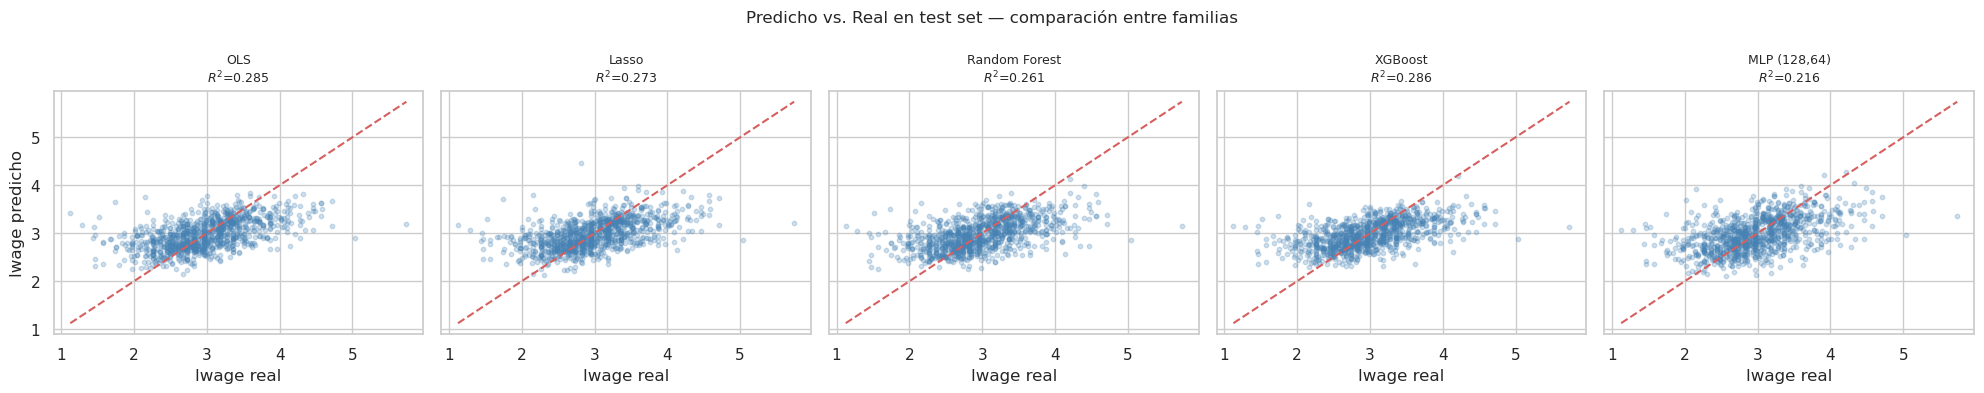

In [37]:
modelos_panel = {
    'OLS':           (ols.predict(X_b_test),          r2_ols),
    'Lasso':         (lasso.predict(X_i_test),        r2_lasso),
    'Random Forest': (rf.predict(X_b_test),           r2_rf),
    'XGBoost':       (xgb_m.predict(X_b_test),        r2_xgb),
    'MLP (128,64)':  (nn_basico.predict(Xb_te_sc),    r2_nn_basico),
}

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True, sharex=True)

for ax, (nombre, (y_pred, r2)) in zip(axes, modelos_panel.items()):
    ax.scatter(y_test, y_pred, alpha=0.25, s=10, color='steelblue')
    lims = [y_test.min(), y_test.max()]
    ax.plot(lims, lims, 'r--', lw=1.5)
    ax.set_title(f'{nombre}\n$R^2$={r2:.3f}', fontsize=9)
    ax.set_xlabel('lwage real')
    if ax == axes[0]:
        ax.set_ylabel('lwage predicho')

fig.suptitle('Predicho vs. Real en test set — comparación entre familias', fontsize=12)
plt.tight_layout()
plt.show()

---
## 11. Brecha salarial de género: análisis de dependencia parcial

**Recordatorio importante**: esto NO es el efecto causal del sexo sobre el salario. Es la diferencia en predicciones cuando se cambia el feature `sex` manteniendo todo lo demás constante.

In [38]:
# ── Construcción de contrafactuales predictivos ────────────────────────────────
X_test_pd = pd.DataFrame(X_b_test, columns=feat_basic)

X_test_mujer  = X_test_pd.copy(); X_test_mujer['sex']  = 1
X_test_hombre = X_test_pd.copy(); X_test_hombre['sex'] = 0

Xm_sc = scaler_b.transform(X_test_mujer.values)
Xh_sc = scaler_b.transform(X_test_hombre.values)

gap_nn       = nn_basico.predict(Xm_sc)             - nn_basico.predict(Xh_sc)
gap_rf_vals  = rf.predict(X_test_mujer.values)      - rf.predict(X_test_hombre.values)
gap_xgb_vals = xgb_m.predict(X_test_mujer.values)   - xgb_m.predict(X_test_hombre.values)

print('Brecha predicha promedio (mujer − hombre, en log-puntos):')
print(f'  MLP (128,64):   {gap_nn.mean():.4f}')
print(f'  Random Forest:  {gap_rf_vals.mean():.4f}')
print(f'  XGBoost:        {gap_xgb_vals.mean():.4f}')

Brecha predicha promedio (mujer − hombre, en log-puntos):
  MLP (128,64):   -0.0495
  Random Forest:  -0.0458
  XGBoost:        -0.0590


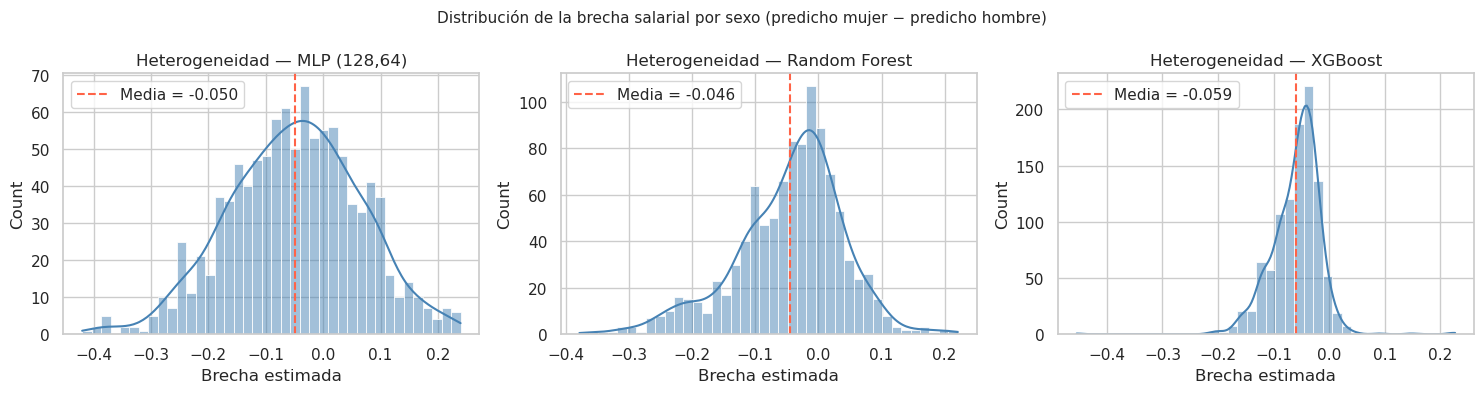

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nombre, gap) in zip(axes, {
    'MLP (128,64)':  gap_nn,
    'Random Forest': gap_rf_vals,
    'XGBoost':       gap_xgb_vals,
}.items()):
    sns.histplot(gap, bins=40, ax=ax, color='steelblue', kde=True)
    ax.axvline(gap.mean(), color='tomato', linestyle='--',
               label=f'Media = {gap.mean():.3f}')
    ax.set_xlabel('Brecha estimada')
    ax.set_title(f'Heterogeneidad — {nombre}')
    ax.legend()

fig.suptitle('Distribución de la brecha salarial por sexo (predicho mujer − predicho hombre)',
             fontsize=11)
plt.tight_layout()
plt.show()

---
## 12. Ejercicio 4 — Brecha salarial por nivel educativo ✅

In [40]:
# ── Brecha por nivel educativo usando el MLP ───────────────────────────────────
niveles_edu = {
    'Sin bachillerato (shs)':  'shs',
    'Bachillerato (hsg)':      'hsg',
    'Algo de universidad (scl)': 'scl',
    'Universitarios (clg)':    'clg',
}

brechas_edu = []

for etiqueta, col in niveles_edu.items():
    # Mascara: filas del test donde la dummy educativa es 1
    mask = X_test_pd[col].values == 1

    if mask.sum() == 0:
        continue

    X_m_edu = X_test_mujer.values[mask]
    X_h_edu = X_test_hombre.values[mask]

    # Escalamos con el scaler ajustado en train
    gap_edu = (
        nn_basico.predict(scaler_b.transform(X_m_edu)) -
        nn_basico.predict(scaler_b.transform(X_h_edu))
    )

    brechas_edu.append({
        'Nivel educativo': etiqueta,
        'Brecha media': gap_edu.mean(),
        'n': mask.sum()
    })
    print(f'{etiqueta:<30}  n={mask.sum():4d}  brecha media = {gap_edu.mean():.4f}')

df_brechas = pd.DataFrame(brechas_edu)

Sin bachillerato (shs)          n=  23  brecha media = -0.1022
Bachillerato (hsg)              n= 273  brecha media = -0.0228
Algo de universidad (scl)       n= 263  brecha media = -0.0310
Universitarios (clg)            n= 317  brecha media = -0.0676


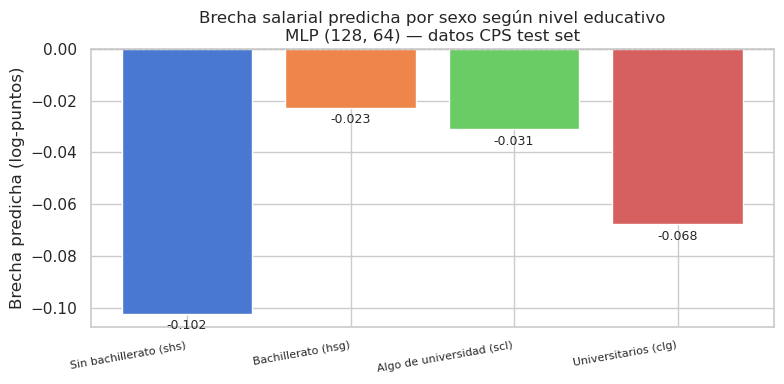

In [41]:
# ── Barplot de brechas por educación ──────────────────────────────────────────
colores_edu = sns.color_palette('muted', len(df_brechas))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    df_brechas['Nivel educativo'],
    df_brechas['Brecha media'],
    color=colores_edu,
    edgecolor='white'
)
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_ylabel('Brecha predicha (log-puntos)')
ax.set_title('Brecha salarial predicha por sexo según nivel educativo\nMLP (128, 64) — datos CPS test set')
ax.tick_params(axis='x', labelsize=8)
plt.xticks(rotation=10, ha='right')
plt.tight_layout()
plt.show()

### Por qué esta brecha NO es causal

El análisis anterior muestra la **heterogeneidad predictiva** de la brecha por género según el nivel educativo. Es tentador interpretarlo como el efecto causal de ser mujer sobre el salario dentro de cada grupo educativo, pero hay al menos tres razones por las que esto no es correcto:

1. **Selección en educación**: Las mujeres y los hombres no se distribuyen aleatoriamente entre niveles educativos. Las características no observadas (motivación, redes sociales, acceso a oportunidades) que determinan tanto la educación como el salario son distintas para hombres y mujeres, lo que genera sesgo de selección.

2. **Variables omitidas**: El modelo usa ocupación (`occ2`) e industria (`ind2`), pero estas variables son en parte por segregación. Controlar por ellas bloquea parte del efecto que nos interesa en un análisis causal, sin que el modelo de predicción lo advierta.

3. **El modelo predice, no identifica**: La red neuronal minimiza el error de predicción. El coeficiente asociado a `sex` no tiene una interpretación estructural; absorbe cualquier correlación entre el sexo y el salario, incluyendo confusores que deberían controlarse en un diseño causal (e.g., con un modelo de variables instrumentales o diferencias en diferencias).

Para estimar causalmente la brecha salarial de género necesitaríamos una estrategia de identificación: un instrumento, variación exógena, o un diseño experimental. Los métodos de ML son aliados del análisis causal (e.g., en el paso de nuisance en Double ML), pero por sí solos no resuelven el problema de identificación.

---
## 13. ¿Por qué los árboles (y las redes) no necesitan las interacciones de Lasso?

- **Lasso y Ridge** son lineales: para capturar que el efecto de la experiencia sobre el salario es diferente para personas con y sin universidad, necesitamos construir explícitamente `exp1 × clg`. De ahí las 246 columnas.

- **Las redes neuronales** aprenden estas interacciones a través de las capas ocultas. Cuando la activación de la segunda capa combina las representaciones aprendidas de `exp1` y `clg`, está implícitamente capturando su interacción — sin que se la especifiquemos.

- **Los árboles** hacen splits condicionales: `exp1 < 14` para `clg=1` y `exp1 < 9.5` para `clg=0` ya modela la interacción.

La diferencia es que los árboles usan particiones (funciones escalonadas) mientras las redes usan composiciones de funciones suaves.

### Recuerden: esto no es causal

Todos los modelos de este laboratorio son herramientas de **predicción**, no de inferencia causal. La diferencia en las predicciones de `sex=0` vs. `sex=1` **no es el efecto causal** del sexo sobre el salario: puede reflejar selección, variables omitidas, y diferencias en ocupaciones y sectores que no controlamos adecuadamente.